## Imports

In [ ]:
import os
import math
import random
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

## DATASET 

In [ ]:
def split_dataset(img_dir, mask_dir, output_dir, split=(0.8, 0.1, 0.1), seed=42):
    random.seed(seed)
    img_dir    = Path(img_dir)
    mask_dir   = Path(mask_dir)
    output_dir = Path(output_dir)

    filenames = sorted([f.stem for f in img_dir.glob("*.jpg")])
    random.shuffle(filenames)

    n       = len(filenames)
    n_train = int(n * split[0])
    n_val   = int(n * split[1])

    splits = {
        "train": filenames[:n_train],
        "val"  : filenames[n_train:n_train + n_val],
        "test" : filenames[n_train + n_val:]
    }

    for split_name, files in splits.items():
        for subfolder in ["images", "masks"]:
            (output_dir / split_name / subfolder).mkdir(parents=True, exist_ok=True)
        for fname in files:
            shutil.copy(img_dir  / f"{fname}.jpg", output_dir / split_name / "images" / f"{fname}.jpg")
            shutil.copy(mask_dir / f"{fname}.jpg", output_dir / split_name / "masks"  / f"{fname}.jpg")
        print(f"{split_name}: {len(files)} samples")


In [ ]:
img_dir    = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
mask_dir   = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"
output_dir = "/kaggle/working/"

In [ ]:
split_dataset(img_dir=img_dir, mask_dir=mask_dir, output_dir=output_dir)

In [ ]:
class MedSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.imgs      = sorted(os.listdir(img_dir))
        self.masks     = sorted(os.listdir(mask_dir))
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img  = np.array(Image.open(os.path.join(self.img_dir,  self.imgs[idx])).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, self.masks[idx])).convert("L"))
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"]
        mask = (mask > 0.5).float().unsqueeze(0)
        return img, mask

## Transforms

In [ ]:
train_tf = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [ ]:
train_ds = MedSegDataset("/kaggle/working/train/images", "/kaggle/working/train/masks", transform=train_tf)
val_ds   = MedSegDataset("/kaggle/working/val/images",   "/kaggle/working/val/masks",   transform=val_tf)
test_ds  = MedSegDataset("/kaggle/working/test/images",  "/kaggle/working/test/masks",  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
# NOTE: batch_size reduced from 16 → 8 because the Transformer bottleneck
# uses more GPU memory than the NonLocalBlock did.

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

## ResNet50 Encoder


In [36]:
class ResNetBottleneck(nn.Module):
    """1×1 → 3×3 → 1×1 bottleneck block. expansion=4."""
    expansion = 4

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1        = nn.BatchNorm2d(planes)
        self.conv2      = nn.Conv2d(planes, planes, kernel_size=3,
                                    stride=stride, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(planes)
        self.conv3      = nn.Conv2d(planes, planes * self.expansion,
                                    kernel_size=1, bias=False)
        self.bn3        = nn.BatchNorm2d(planes * self.expansion)
        self.relu       = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNet50Encoder(nn.Module):
    """
    ResNet50 backbone. Returns 3 skip connections.

    skip_1 : (B,  256, H/4,  W/4 )
    skip_2 : (B,  512, H/8,  W/8 )
    skip_3 : (B, 1024, H/16, W/16)  ← fed into Transformer
    """
    def __init__(self):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )                                                    # (B,   64, H/4,  W/4)

        self.stage1 = self._make_layer(64,  blocks=3, stride=1)  # (B,  256, H/4,  W/4)
        self.stage2 = self._make_layer(128, blocks=4, stride=2)  # (B,  512, H/8,  W/8)
        self.stage3 = self._make_layer(256, blocks=6, stride=2)  # (B, 1024, H/16, W/16)
        self.stage4 = self._make_layer(512, blocks=3, stride=2)  # (B, 2048, H/32, W/32) — unused

    def _make_layer(self, planes, blocks, stride):
        out_ch     = planes * ResNetBottleneck.expansion
        downsample = None

        if stride != 1 or self.in_channels != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_ch,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

        layers = [ResNetBottleneck(self.in_channels, planes, stride, downsample)]
        self.in_channels = out_ch
        for _ in range(1, blocks):
            layers.append(ResNetBottleneck(self.in_channels, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x      = self.stem(x)
        skip_1 = self.stage1(x)        # (B,  256, H/4,  W/4)
        skip_2 = self.stage2(skip_1)   # (B,  512, H/8,  W/8)
        skip_3 = self.stage3(skip_2)   # (B, 1024, H/16, W/16)
        _      = self.stage4(skip_3)   # not returned
        return skip_1, skip_2, skip_3

## TRANSFORMER ENCODER  (ViT-B style)

In [37]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        attn = self.dropout((q @ k.transpose(-2, -1)) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1, 2).reshape(B, N, C))


class FeedForward(nn.Module):
    def __init__(self, embed_dim, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Pre-LN: x = x + Attn(Norm(x)),  x = x + FFN(Norm(x))"""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn   = FeedForward(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """
    Transformer applied on ResNet50 Stage3 feature map.

      1×1 conv  : 1024 → embed_dim
      flatten   : (B, embed_dim, H, W) → (B, N, embed_dim)
      + pos_embed
      depth × TransformerBlock
      reshape   : (B, N, embed_dim) → (B, embed_dim, H, W)

    Paper: depth=12, embed_dim=768, heads=12 (ViT-B)
    Here:  depth=6,  embed_dim=512, heads=8  (lighter, no pretraining)
    """
    def __init__(self, in_channels=1024, embed_dim=512,
                 depth=6, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.patch_proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)
        self.patch_norm = nn.LayerNorm(embed_dim)
        self.pos_embed  = nn.Parameter(torch.zeros(1, 256, embed_dim))  # 16×16=256 for 256×256 input
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.pos_drop   = nn.Dropout(dropout)
        self.blocks     = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.patch_proj(x)                      # (B, embed_dim, H, W)
        x = x.flatten(2).transpose(1, 2)            # (B, N, embed_dim)
        x = self.patch_norm(x)

        # Interpolate pos_embed if spatial size differs from 256 tokens
        if x.size(1) != self.pos_embed.size(1):
            ph = pw = int(math.sqrt(self.pos_embed.size(1)))
            pos = self.pos_embed.transpose(1, 2).reshape(1, -1, ph, pw)
            pos = F.interpolate(pos, size=(H, W), mode='bilinear', align_corners=False)
            pos = pos.flatten(2).transpose(1, 2)
        else:
            pos = self.pos_embed

        x = self.pos_drop(x + pos)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)                             # (B, N, embed_dim)
        return x.transpose(1, 2).reshape(B, -1, H, W)  # (B, embed_dim, H, W)


## CUP DECODER  (Cascaded UPsampler)

In [38]:
class CUPDecoderBlock(nn.Module):
    """
    Conv3×3+BN+ReLU → Upsample 2× → Concat(skip) → Conv3×3+BN+ReLU × 2

    Different from standard decoder (which upsamples first then conv).
    Paper refines features BEFORE upsampling.

    Args:
        in_channels   : from previous decoder stage
        skip_channels : from encoder skip (0 = no skip)
        out_channels  : output channels
    """
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv_before = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        fused = in_channels + skip_channels
        self.conv_after = nn.Sequential(
            nn.Conv2d(fused, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )

    def forward(self, x, skip=None):
        x = self.conv_before(x)
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        if skip is not None:
            if skip.shape[2:] != x.shape[2:]:
                skip = F.interpolate(skip, size=x.shape[2:],
                                     mode='bilinear', align_corners=True)
            x = torch.cat([x, skip], dim=1)
        return self.conv_after(x)


## TRANSUNET

In [39]:
class TransUNet(nn.Module):
    """
    Flow (256×256 input):
      ResNet50 Encoder
        Stage1 → skip_1 (B,  256,  64,  64)
        Stage2 → skip_2 (B,  512,  32,  32)
        Stage3 → skip_3 (B, 1024,  16,  16)  ← also Transformer input
      ViT Encoder on skip_3
        → t     (B,  512,  16,  16)
      CUP Decoder
        dec1: t  + skip_3_proj(512) → (B, 256, 32, 32)
        dec2: d1 + skip_2    (512) → (B, 128, 64, 64)
        dec3: d2 + skip_1    (256) → (B,  64,128,128)
        dec4: d3 + no skip         → (B,  16,256,256)
      Seg head → (B, 1, 256, 256)
    """
    def __init__(
        self,
        num_classes       = 1,
        embed_dim         = 512,
        transformer_depth = 6, # in the paper they use 12 transformer layer as they train their model with ImageNet dataset that is Huge for my case Kvasir-SEG dataset 6 is good
        num_heads         = 8, 
        mlp_ratio         = 4,
        dropout           = 0.1
    ):
        super().__init__()

        self.encoder    = ResNet50Encoder()

        self.vit        = ViTEncoder(
            in_channels = 1024,
            embed_dim   = embed_dim,
            depth       = transformer_depth,
            num_heads   = num_heads,
            mlp_ratio   = mlp_ratio,
            dropout     = dropout
        )

        # Project skip_3 (1024) → embed_dim (512) before concat in dec1
        self.skip3_proj = nn.Sequential(
            nn.Conv2d(1024, embed_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(inplace=True)
        )

        self.dec1 = CUPDecoderBlock(embed_dim, embed_dim, 256)  # + skip_3 projected
        self.dec2 = CUPDecoderBlock(256,       512,        128)  # + skip_2
        self.dec3 = CUPDecoderBlock(128,       256,         64)  # + skip_1
        self.dec4 = CUPDecoderBlock( 64,         0,         16)  # no skip

        self.seg_head = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        skip_1, skip_2, skip_3 = self.encoder(x)

        t           = self.vit(skip_3)           # (B, 512,  16, 16)
        skip_3_proj = self.skip3_proj(skip_3)    # (B, 512,  16, 16)

        d1 = self.dec1(t,  skip_3_proj)          # (B, 256,  32, 32)
        d2 = self.dec2(d1, skip_2)               # (B, 128,  64, 64)
        d3 = self.dec3(d2, skip_1)               # (B,  64, 128,128)
        d4 = self.dec4(d3, None)                 # (B,  16, 256,256)

        return self.seg_head(d4)                 # (B,   1, 256,256)

##  LOSS & METRICS 

In [40]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()   # ← NOTE: changed from BCELoss
        self.smooth = smooth                    # BCEWithLogitsLoss is numerically
                                                # more stable (fused sigmoid+BCE)

    def dice_loss(self, pred, target):
        pred         = torch.sigmoid(pred)      # apply sigmoid since we use logits
        intersection = (pred * target).sum(dim=(2, 3))
        union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice         = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice_loss(pred, target)


def dice_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()


def iou_score(pred, target, threshold=0.5, smooth=1e-6):
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

## TRAINING LOOP 

In [41]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()

        if scaler is not None:
            # AMP (Automatic Mixed Precision) — optional, saves GPU memory
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss  = criterion(preds, masks)
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            preds = model(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    for imgs, masks in tqdm(loader, desc="Val  ", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        total_loss += loss.item()
        total_dice += dice_score(preds, masks)
        total_iou  += iou_score(preds, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

## PLOT 

In [42]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"],   label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_dice"], label="Train")
    axes[1].plot(epochs, history["val_dice"],   label="Val")
    axes[1].set_title("Dice Score"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["train_iou"], label="Train")
    axes[2].plot(epochs, history["val_iou"],   label="Val")
    axes[2].set_title("IoU Score"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_history_transunet.png", dpi=150)
    plt.show()

## TRAIN FUNCTION

In [43]:
def train(model, train_loader, val_loader, epochs=50, lr=1e-4, device="cuda"):
    criterion = BCEDiceLoss()

    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    # Optional: AMP scaler (set to None to disable, saves memory if enabled)
    scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou" : [], "val_iou" : []
    }

    best_dice = 0.0

    for epoch in range(1, epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler
        )
        val_loss, val_dice, val_iou = evaluate(model, val_loader, criterion, device)

        scheduler.step()  # CosineAnnealingLR steps every epoch (not on val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(f"Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {train_loss:.4f}/{val_loss:.4f}  "
              f"Dice: {train_dice:.4f}/{val_dice:.4f}  "
              f"IoU: {train_iou:.4f}/{val_iou:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), "best_transunet.pth")
            print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

    plot_history(history)
    return history

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransUNet(
    num_classes       = 1,
    embed_dim         = 512,
    transformer_depth = 12,
    num_heads         = 8,
    mlp_ratio         = 4,
    dropout           = 0.1
).to(device)

/tmp/ipykernel_55/4119995683.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device == "cuda" else None


✓ Shape check passed: torch.Size([2, 1, 256, 256])
  Total params: 69,889,553


Train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/3252445767.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [01/50]  Loss: 1.3478/1.3129  Dice: 0.4143/0.5051  IoU: 0.2878/0.3641
  ✓ Best model saved (Dice: 0.5051)


Epoch [02/50]  Loss: 1.2549/1.2487  Dice: 0.4707/0.5259  IoU: 0.3385/0.3842
  ✓ Best model saved (Dice: 0.5259)


...

Epoch [46/50]  Loss: 0.4918/0.5974  Dice: 0.8755/0.8336  IoU: 0.8034/0.7537


Epoch [47/50]  Loss: 0.4893/0.6071  Dice: 0.8782/0.8377  IoU: 0.8054/0.7580
  ✓ Best model saved (Dice: 0.8377)


Epoch [48/50]  Loss: 0.4885/0.5892  Dice: 0.8785/0.8275  IoU: 0.8069/0.7479


Epoch [49/50]  Loss: 0.4858/0.5973  Dice: 0.8784/0.8201  IoU: 0.8074/0.7396


Epoch [50/50]  Loss: 0.4883/0.6463  Dice: 0.8772/0.8282  IoU: 0.8061/0.7484


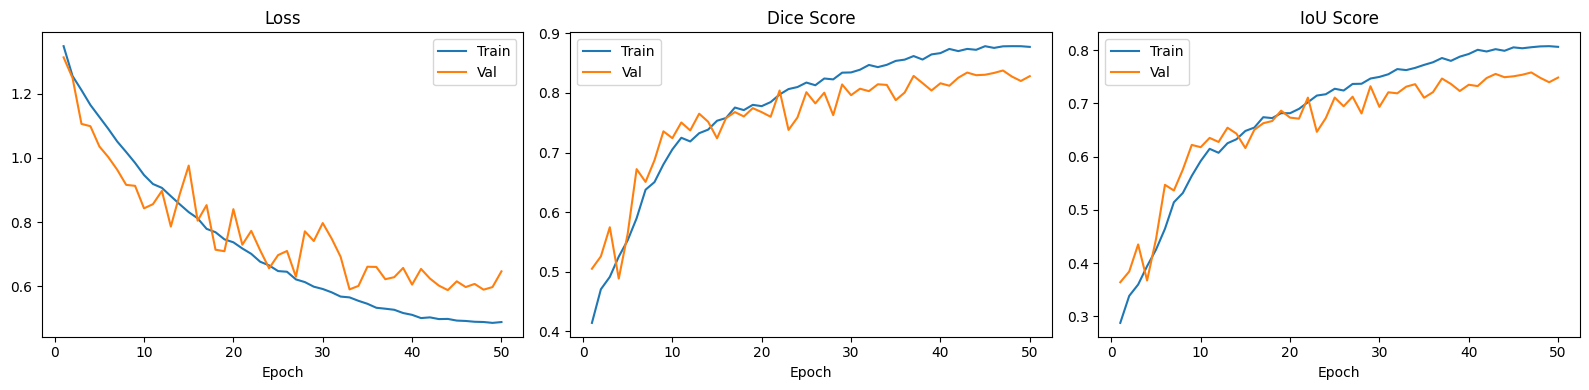

In [45]:
# Shape check
dummy = torch.randn(2, 3, 256, 256).to(device)
out   = model(dummy)
assert out.shape == (2, 1, 256, 256), f"Shape error: {out.shape}"
print(f"✓ Shape check passed: {out.shape}")
print(f"  Total params: {sum(p.numel() for p in model.parameters()):,}")

history = train(model, train_loader, val_loader, epochs=50, lr=1e-4, device=device)

## INFERENCE & VISUALIZATION

In [47]:
infer_tf = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2()
])


@torch.no_grad()
def predict(model, image_path, device, threshold=0.5):
    img         = np.array(Image.open(image_path).convert("RGB"))
    original    = img.copy()
    transformed = infer_tf(image=img)["image"].unsqueeze(0).to(device)
    pred        = torch.sigmoid(model(transformed))
    pred_mask   = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)
    return original, pred_mask


def visualize(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    fig.suptitle("TransUNet — Image | Ground Truth | Prediction",
                 fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.uint8)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)
        gt   = mask_tensor.squeeze().numpy()

        axes[row, 0].imshow(img);              axes[row, 0].set_title("Image");        axes[row, 0].axis("off")
        axes[row, 1].imshow(gt,   cmap="gray"); axes[row, 1].set_title("Ground Truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(pred_mask, cmap="gray"); axes[row, 2].set_title("Prediction"); axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig("inference_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


def visualize_overlay(model, dataset, device, num_samples=6, threshold=0.5):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    fig.suptitle("TransUNet — Prediction Overlay",
                 fontsize=16, fontweight="bold")

    for row, idx in enumerate(indices):
        img_tensor, _ = dataset[idx]

        with torch.no_grad():
            pred      = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
            pred_mask = (pred.squeeze().cpu().numpy() > threshold).astype(np.float32)

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img_tensor.permute(1, 2, 0).numpy()
        img  = (img * std + mean).clip(0, 1)

        overlay              = img.copy()
        overlay[pred_mask == 1] = [1.0, 0.0, 0.0]
        blended              = (0.6 * img + 0.4 * overlay).clip(0, 1)

        axes[row, 0].imshow(img);     axes[row, 0].set_title("Original");           axes[row, 0].axis("off")
        axes[row, 1].imshow(blended); axes[row, 1].set_title("Prediction Overlay"); axes[row, 1].axis("off")

    plt.tight_layout()
    plt.savefig("overlay_transunet.png", dpi=150, bbox_inches="tight")
    plt.show()


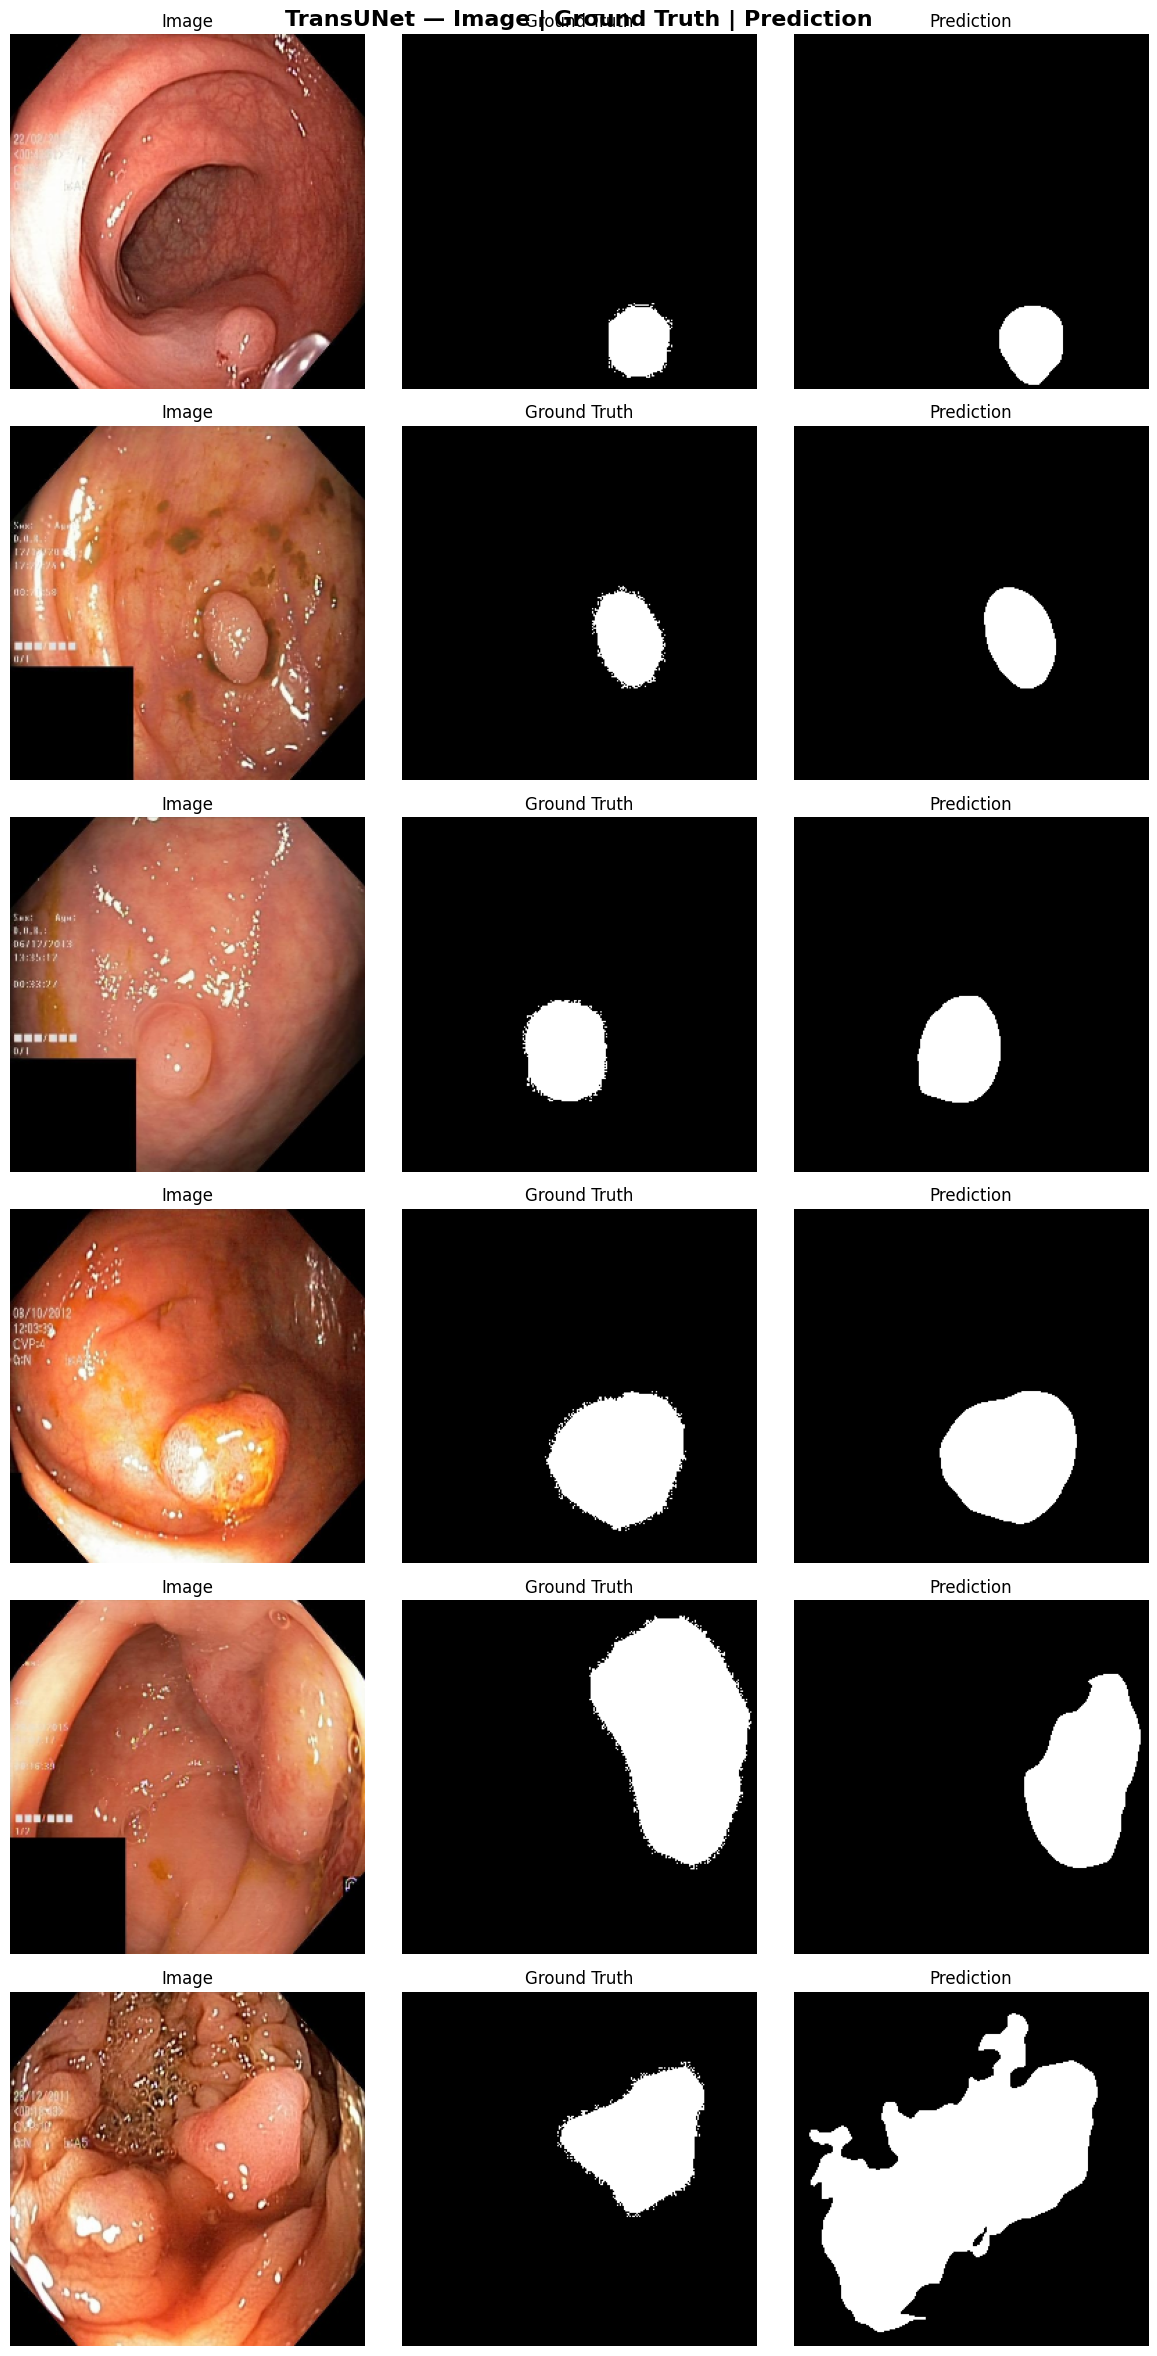

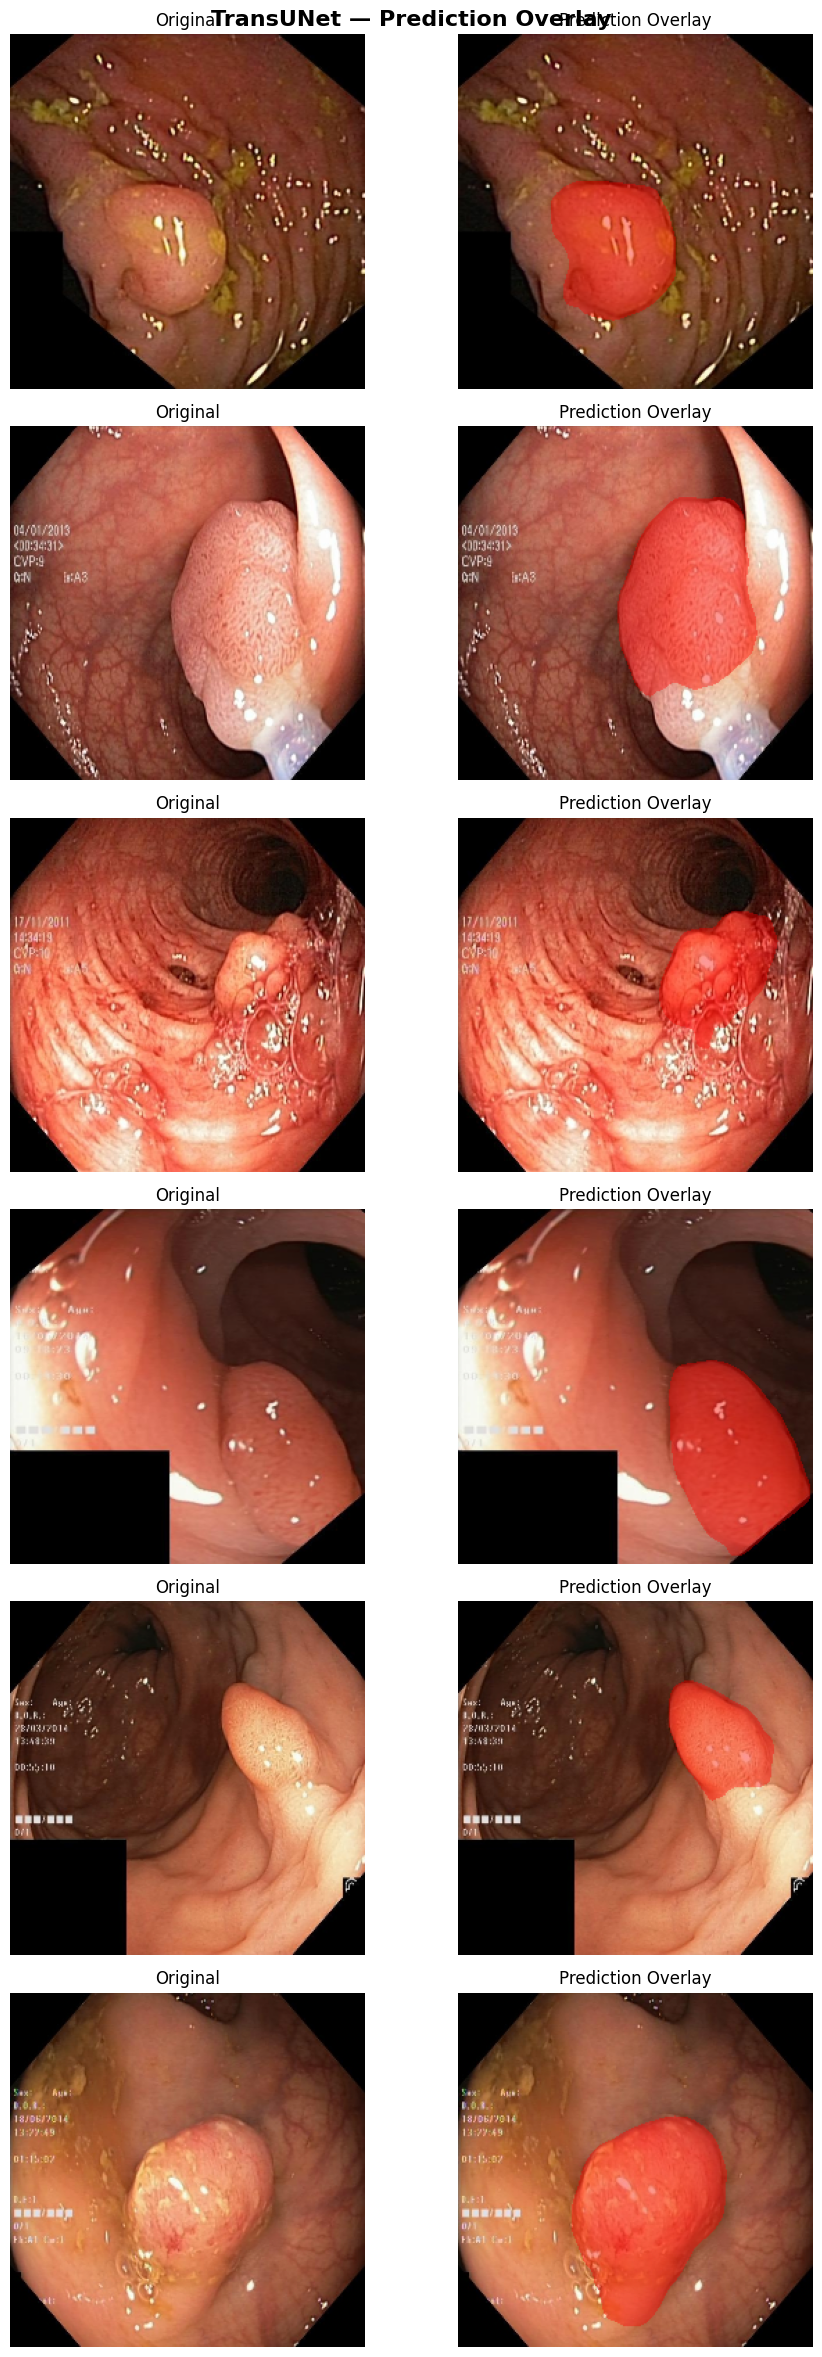

In [49]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransUNet(
    num_classes       = 1,
    transformer_depth = 12,   # ← was 6, now matches checkpoint
).to(device)
model.load_state_dict(torch.load("best_transunet.pth", map_location=device))
model.eval()

visualize(model, test_ds, device, num_samples=6)
visualize_overlay(model, test_ds, device, num_samples=6)